In [6]:
%matplotlib inline
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# parent directory to path for imports
sys.path.append(str(Path.cwd().parent))

#  import utility functions from existing modules
from train_cvae import load_data
from ae_utils import _encode, _decode

In [7]:
root = Path.cwd().parent
dataset_type = 'mnist'

# model config
if dataset_type == 'mnist':
    checkpoint_path = root / 'ASAB/runs/0904_mnist/vae_1.pth'
    input_dim = 784  # 28x28
    latent_dim = 12
    data_csv = None  # MNIST is from torchvision
    num_classes = 10

# load data
X_train_tensor, X_valid_tensor, X, _, y_train = load_data(
    data_csv=data_csv, 
    dataset=dataset_type, 
    single_class=None)

labels head(): [5 0 4 1 9]


In [8]:
target_class = 3
latent_vectors = _encode(target_class,
                        num_classes,
                        input_dim,
                        latent_dim,
                        checkpoint_path,
                        dataset_type, 
                        X_train_tensor,
                        y_train)

print(latent_vectors)

tensor([[-9.6239e-01, -2.2566e-03,  5.5411e-02,  ..., -1.9129e-02,
          4.5099e-02,  8.8036e-02],
        [-1.2478e+00,  5.8252e-02,  1.5338e-02,  ..., -2.1789e-02,
          3.0272e-03, -1.3173e+00],
        [-1.3873e+00,  2.2121e-02,  8.8080e-02,  ..., -8.9055e-03,
          4.2497e-02, -4.6747e-01],
        ...,
        [ 1.9047e-01,  3.0537e-02, -5.3465e-02,  ..., -2.2784e-03,
         -2.9262e-03, -6.8574e-01],
        [-1.0785e+00,  5.0942e-03,  3.5502e-02,  ..., -2.6849e-02,
          4.8820e-02,  6.1585e-01],
        [-1.1928e-01,  1.1426e-03,  2.0655e-02,  ..., -9.9753e-03,
          2.1875e-02,  3.0648e-01]])


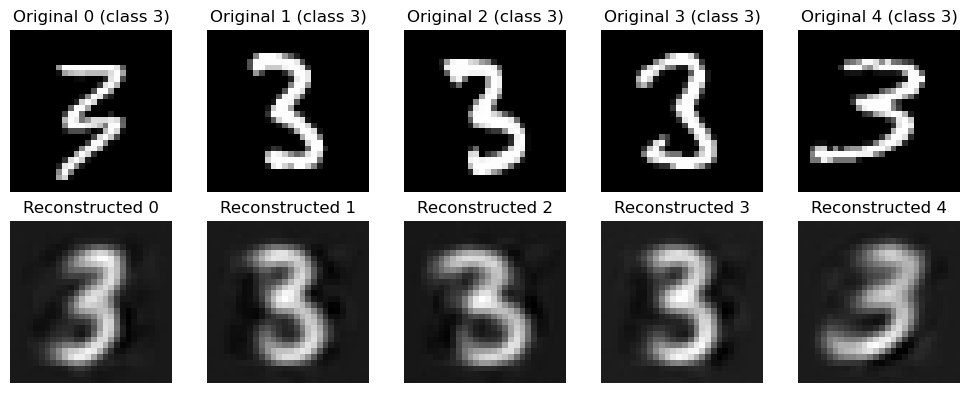

In [10]:
# Get only class 3 samples from training data
class_3_mask = y_train == target_class
X_train_class_3 = X_train_tensor[class_3_mask]

# reconstruct and plot
reconstructed = _decode(
   latent_vectors,
   target_class,
    num_classes,
    input_dim,
    latent_dim,
    checkpoint_path,
    dataset_type
)

# plot original vs reconstructed
n = min(5, len(latent_vectors))
fig, axes = plt.subplots(2, n, figsize=(n*2, 4))

for i in range(n):
    # Original (filtered for class 3)
    orig = X_train_class_3[i].numpy().reshape(28, 28)
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'Original {i} (class 3)')
    axes[0, i].axis('off')
    
    # Reconstructed
    recon = reconstructed[i].reshape(28, 28)
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].set_title(f'Reconstructed {i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()